
# Models Included:
1. **Baseline Models**: Logistic Regression
2. **Feature Engineering**: Bag of Words (BOW), TF-IDF, BERT Embeddings
3. **Tree-based Models**: XGBoost, LightGBM
4. **Deep Learning**: LSTM, Fine-tuned BERT
5. **Ensemble**: Weighted averaging of top models

## Setup and Data Loading

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Add src to path
sys.path.insert(0, '..')

from src import (
    load_data,
    engineer_features,
    evaluate_model,
    print_evaluation_report
)

%matplotlib inline
sns.set_style('whitegrid')

### Load and Prepare Data

In [ ]:
# Load datasets
df_train, df_test = load_data(
    '../data/quora_question_pairs_train.csv.zip',
    '../data/quora_question_pairs_test.csv.zip'
)

# Engineer features
df_train = engineer_features(df_train)

# Prepare features
feature_cols = ['q1_len', 'q2_len', 'len_diff', 'common_words', 'jaccard_sim', 'word_match_share']
X = df_train[feature_cols]
y = df_train['is_duplicate']

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data prepared for training")
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

#Baseline

Baseline Model Performance:
Log Loss: 0.42
F1-score: 0.69


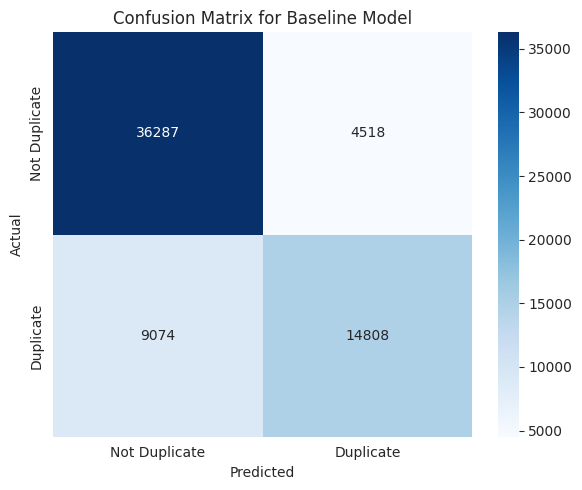


Classification Report:
               precision    recall  f1-score   support

Not Duplicate       0.80      0.89      0.84     40805
    Duplicate       0.77      0.62      0.69     23882

     accuracy                           0.79     64687
    macro avg       0.78      0.75      0.76     64687
 weighted avg       0.79      0.79      0.78     64687



In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define features and target
features = [
    "len_diff",
    "common_words",
    "jaccard_sim",
    "word_match_share",
    "max_q_freq",
    "min_q_freq",
]
X = df_train[features]
y = df_train["is_duplicate"]

# Handle potential NaN values in feature columns (fill with 0 for simplicity)
X = X.fillna(0)

# Split the data into training and validation sets, ensuring class balance.
# This split creates a *validation set* (X_val, y_val) from the training data.
# The purpose of this validation set is to tune hyperparameters and evaluate model
# performance during development to avoid overfitting to the training data.
# The 'df_test' dataset, which was loaded separately, is reserved for final, unbiased
# evaluation *after* the model has been fully developed and selected using the
# training and validation sets.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features to improve model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Initialize and train a Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train_scaled, y_train)

# Predict probabilities for Log Loss
y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

# Predict classes for F1-score
y_pred = model.predict(X_val_scaled)

# Calculate evaluation metrics
logloss = log_loss(y_val, y_pred_proba)
f1 = f1_score(y_val, y_pred)

# Print the metrics
print(f"Baseline Model Performance:")
print(f"Log Loss: {logloss:.2f}")
print(f"F1-score: {f1:.2f}")

# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Baseline Model")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["Not Duplicate", "Duplicate"]))

Baseline Logistic Regression model achieved a Log Loss of 0.42, F1-score of 0.69. This indicates fairly good performance for a baseline model, especially given the class imbalance. F1-score indicates an acceptable balance between precision and recall in detecting duplicate queries

Bag of Words

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# Combine question1 and question2 for CountVectorizer training to create a comprehensive vocabulary
# from all questions in the training set.
train_questions_combined = pd.concat([df_train['question1'], df_train['question2']]).astype(str).apply(preprocess_text)

bow_vectorizer = CountVectorizer(max_features=10000, stop_words=list(stops))
bow_vectorizer.fit(train_questions_combined)

# Transform question1 and question2 using the fitted vectorizer
%time X_train_q1_bow = bow_vectorizer.transform(df_train['question1'].astype(str).apply(preprocess_text))
%time X_train_q2_bow = bow_vectorizer.transform(df_train['question2'].astype(str).apply(preprocess_text))

print("Bag of Words features for question1 shape:", X_train_q1_bow.shape)
print("Bag of Words features for question2 shape:", X_train_q2_bow.shape)

CPU times: user 9.31 s, sys: 22.1 ms, total: 9.33 s
Wall time: 9.34 s
CPU times: user 10.4 s, sys: 21 ms, total: 10.4 s
Wall time: 10.5 s
Bag of Words features for question1 shape: (323432, 10000)
Bag of Words features for question2 shape: (323432, 10000)


Logistic Regression with BOW Features Performance:
Log Loss: 0.60
F1-score: 0.61


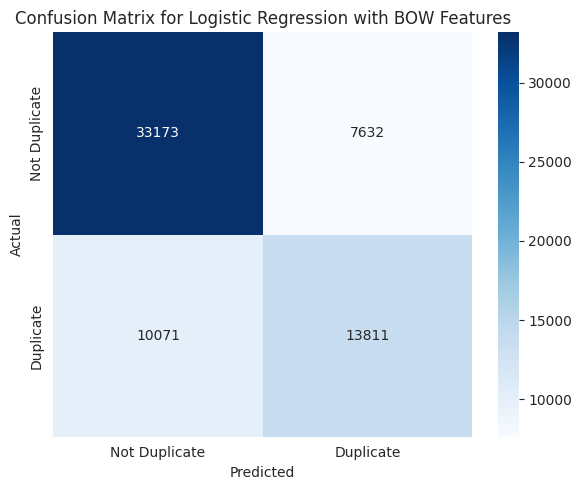


Classification Report for BOW Features:
               precision    recall  f1-score   support

Not Duplicate       0.77      0.81      0.79     40805
    Duplicate       0.64      0.58      0.61     23882

     accuracy                           0.73     64687
    macro avg       0.71      0.70      0.70     64687
 weighted avg       0.72      0.73      0.72     64687



In [17]:
from scipy.sparse import hstack

# Combine BOW features for question1 and question2 while keeping them sparse
X_bow = hstack([X_train_q1_bow, X_train_q2_bow])

# Split the data into training and validation sets for BOW features
X_train_bow, X_val_bow, y_train_bow, y_val_bow = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the BOW features
scaler_bow = StandardScaler(with_mean=False)
X_train_bow_scaled = scaler_bow.fit_transform(X_train_bow)
X_val_bow_scaled = scaler_bow.transform(X_val_bow)

# Initialize and train a Logistic Regression model with BOW features
model_bow = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model_bow.fit(X_train_bow_scaled, y_train_bow)

# Predict probabilities for Log Loss
y_pred_proba_bow = model_bow.predict_proba(X_val_bow_scaled)[:, 1]

# Predict classes for F1-score
y_pred_bow = model_bow.predict(X_val_bow_scaled)

# Calculate evaluation metrics
logloss_bow = log_loss(y_val_bow, y_pred_proba_bow)
f1_bow = f1_score(y_val_bow, y_pred_bow)

# Print the metrics
print(f"Logistic Regression with BOW Features Performance:")
print(f"Log Loss: {logloss_bow:.2f}")
print(f"F1-score: {f1_bow:.2f}")

# Calculate the confusion matrix
cm_bow = confusion_matrix(y_val_bow, y_pred_bow)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bow, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Logistic Regression with BOW Features")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report for BOW Features:")
print(classification_report(y_val_bow, y_pred_bow, target_names=["Not Duplicate", "Duplicate"]))

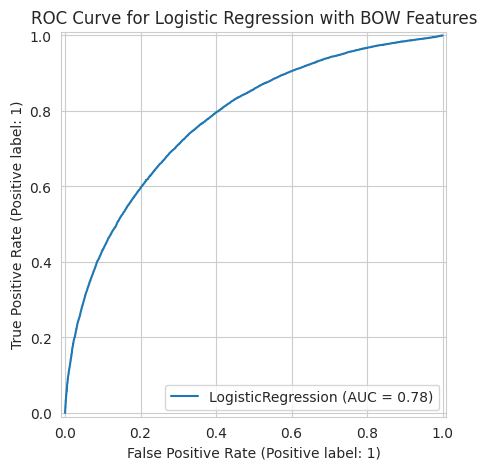

In [18]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
disp = RocCurveDisplay.from_estimator(model_bow, X_val_bow_scaled, y_val_bow, ax=ax)
ax.set_title("ROC Curve for Logistic Regression with BOW Features")
plt.show()

Logistic Regression model using “Bag-of-Words” features showed a Log Loss of 0,60 and an F1 score of 0,61. Although the overall accuracy is 0,73, the F1 score for questions in the “Duplicate” category is 0,61 (precision 0,64, recall 0,58), and for questions in the “Not a Duplicate” category, it is 0.79 (precision 0,77, recall 0,81). Compared to the baseline model (Log Loss: 0,42, F1 score: 0,69), the BOW model demonstrates slightly lower performance in identifying duplicate question pairs

TF-IDF

CPU times: user 10.4 s, sys: 37 ms, total: 10.4 s
Wall time: 10.5 s
CPU times: user 10.5 s, sys: 26 ms, total: 10.5 s
Wall time: 10.6 s
TF-IDF features for question1 shape: (323432, 10000)
TF-IDF features for question2 shape: (323432, 10000)

Logistic Regression with TF-IDF Features Performance:
Log Loss: 0.62
F1-score: 0.61


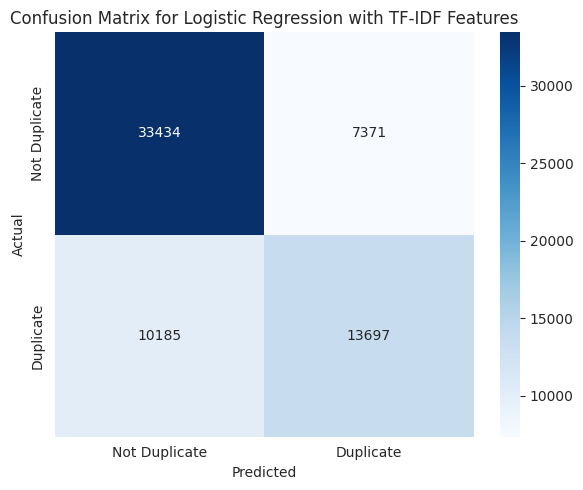


Classification Report for TF-IDF Features:
               precision    recall  f1-score   support

Not Duplicate       0.77      0.82      0.79     40805
    Duplicate       0.65      0.57      0.61     23882

     accuracy                           0.73     64687
    macro avg       0.71      0.70      0.70     64687
 weighted avg       0.72      0.73      0.72     64687



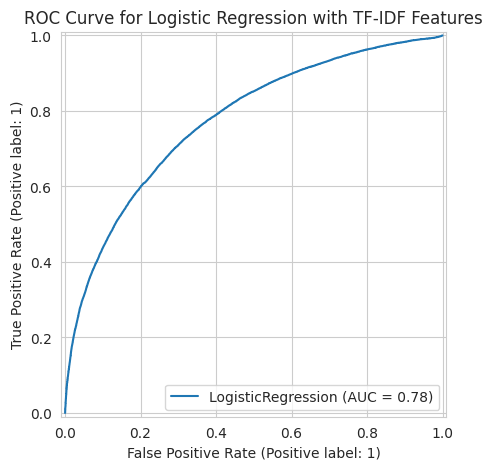

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine question1 and question2 for TfidfVectorizer training to create a comprehensive vocabulary
# from all questions in the training set.
train_questions_combined = pd.concat([df_train['question1'], df_train['question2']]).astype(str).apply(preprocess_text)

tfidf_vectorizer = TfidfVectorizer(max_features=10000, stop_words=list(stops))
tfidf_vectorizer.fit(train_questions_combined)

# Transform question1 and question2 using the fitted vectorizer
%time X_train_q1_tfidf = tfidf_vectorizer.transform(df_train['question1'].astype(str).apply(preprocess_text))
%time X_train_q2_tfidf = tfidf_vectorizer.transform(df_train['question2'].astype(str).apply(preprocess_text))

print("TF-IDF features for question1 shape:", X_train_q1_tfidf.shape)
print("TF-IDF features for question2 shape:", X_train_q2_tfidf.shape)

from scipy.sparse import hstack

# Combine TF-IDF features for question1 and question2 while keeping them sparse
X_tfidf = hstack([X_train_q1_tfidf, X_train_q2_tfidf])

# Split the data into training and validation sets for TF-IDF features
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the TF-IDF features
# TF-IDF features are already normalized, but scaling can sometimes still help certain models.
# We'll use StandardScaler with with_mean=False as TF-IDF is sparse and already centered around zero for feature values.
scaler_tfidf = StandardScaler(with_mean=False)
X_train_tfidf_scaled = scaler_tfidf.fit_transform(X_train_tfidf)
X_val_tfidf_scaled = scaler_tfidf.transform(X_val_tfidf)

# Initialize and train a Logistic Regression model with TF-IDF features
model_tfidf = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model_tfidf.fit(X_train_tfidf_scaled, y_train_tfidf)

# Predict probabilities for Log Loss
y_pred_proba_tfidf = model_tfidf.predict_proba(X_val_tfidf_scaled)[:, 1]

# Predict classes for F1-score
y_pred_tfidf = model_tfidf.predict(X_val_tfidf_scaled)

# Calculate evaluation metrics
logloss_tfidf = log_loss(y_val_tfidf, y_pred_proba_tfidf)
f1_tfidf = f1_score(y_val_tfidf, y_pred_tfidf)

# Print the metrics
print(f"\nLogistic Regression with TF-IDF Features Performance:")
print(f"Log Loss: {logloss_tfidf:.2f}")
print(f"F1-score: {f1_tfidf:.2f}")

# Calculate the confusion matrix
cm_tfidf = confusion_matrix(y_val_tfidf, y_pred_tfidf)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Logistic Regression with TF-IDF Features")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report for TF-IDF Features:")
print(classification_report(y_val_tfidf, y_pred_tfidf, target_names=["Not Duplicate", "Duplicate"]))

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
disp = RocCurveDisplay.from_estimator(model_tfidf, X_val_tfidf_scaled, y_val_tfidf, ax=ax)
ax.set_title("ROC Curve for Logistic Regression with TF-IDF Features")
plt.show()


Logistic Regression model using TF-IDF features achieved a Log Loss of 0.62 and an F1-score of 0.61.

Compared to the “Bag-of-Words” model, the results are very similar (in the BOW model, the Log Loss was 0.60 and the F1-score was 0.61).

However, both the TF-IDF model and the “Bag-of-Words” model performed slightly worse than the baseline model, which used manually crafted features (Log Loss: 0.42, F1-score: 0.69).

Specifically, for the “Duplicate” class, TF-IDF achieved an F1-score of 0.61 (precision 0.65, recall 0.57), while for the “Non-duplicate” class, it achieved 0.79 (precision 0.77, recall 0.82). This indicates that, although TF-IDF is capable of accounting for certain textual nuances, it does not demonstrate significantly better results compared to simple word counting or manually crafted features for this specific task, and the baseline model still provides a better balance of precision and recall for duplicate detection

BERT Embeddings

In [20]:
import sys
!{sys.executable} -m pip install transformers torch

# Import libraries
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, f1_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load a pre-trained BERT model and tokenizer (e.g., DistilBERT)
# DistilBERT is smaller and faster than BERT, suitable for Colab.
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model_bert = AutoModel.from_pretrained("distilbert-base-uncased")

# Set the model to evaluation mode and move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)
model_bert.eval() # Set model to evaluation mode

# Define a function to get BERT embeddings in batches
def get_bert_embeddings(texts, tokenizer, model, device, batch_size=64, max_length=128):
    all_embeddings = []
    # Process texts in batches
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        # Preprocess each text using the user's defined preprocess_text function
        # preprocess_text is defined in a previous cell and handles lowercasing, punctuation removal,
        # stop word removal, and lemmatization.
        preprocessed_batch_texts = [preprocess_text(text) for text in batch_texts]

        # Tokenize the preprocessed texts
        encoded_input = tokenizer(
            preprocessed_batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        # Move tensors to the appropriate device
        input_ids = encoded_input['input_ids'].to(device)
        attention_mask = encoded_input['attention_mask'].to(device)

        with torch.no_grad(): # Disable gradient calculations for inference
            output = model(input_ids=input_ids, attention_mask=attention_mask)

        # Get the embeddings from the last hidden state and apply mean pooling
        # Mean pooling across the token dimension (dim=1)
        # We also multiply by the attention mask to ignore padded tokens
        embeddings = (output.last_hidden_state * attention_mask.unsqueeze(-1)).sum(dim=1) / attention_mask.sum(dim=1).unsqueeze(-1)
        all_embeddings.append(embeddings.cpu().numpy()) # Move to CPU and convert to numpy

    return np.vstack(all_embeddings)

# Ensure 'y' (is_duplicate) is available for train_test_split
# This variable should have been defined in previous cells (e.g., Baseline Model section)
# If not, it will be defined here.
if 'y' not in globals(): # Use globals() to check for global scope variables
    if 'df_train' in globals() and 'is_duplicate' in df_train.columns:
        y = df_train["is_duplicate"]
    else:
        print("Error: df_train or 'is_duplicate' column not found. Please ensure data is loaded and 'y' is defined.")
        # Depending on the criticality, you might want to exit or raise an error here.
        # For now, we'll proceed, but subsequent steps might fail if y is truly missing.

# Set a chunk size for processing the dataframe to manage memory
df_chunk_size = 500 # Further reduced to manage RAM more effectively

print("Generating BERT embeddings for question1...")
all_q1_embeddings_list = []
%time
for i in range(0, len(df_train), df_chunk_size):
    current_chunk = df_train.iloc[i : i + df_chunk_size]
    q1_texts_chunk = current_chunk['question1'].astype(str).tolist()
    chunk_embeddings = get_bert_embeddings(q1_texts_chunk, tokenizer, model_bert, device)
    all_q1_embeddings_list.append(chunk_embeddings)
    print(f"Processed {min(i + df_chunk_size, len(df_train))} / {len(df_train)} for question1")

X_train_q1_bert = np.vstack(all_q1_embeddings_list)
print("\nBERT embeddings for question1 shape:", X_train_q1_bert.shape)


print("\nGenerating BERT embeddings for question2...")
all_q2_embeddings_list = []
%time
for i in range(0, len(df_train), df_chunk_size):
    current_chunk = df_train.iloc[i : i + df_chunk_size]
    q2_texts_chunk = current_chunk['question2'].astype(str).tolist()
    chunk_embeddings = get_bert_embeddings(q2_texts_chunk, tokenizer, model_bert, device)
    all_q2_embeddings_list.append(chunk_embeddings)
    print(f"Processed {min(i + df_chunk_size, len(df_train))} / {len(df_train)} for question2")

X_train_q2_bert = np.vstack(all_q2_embeddings_list)
print("\nBERT embeddings for question2 shape:", X_train_q2_bert.shape)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating BERT embeddings for question1...
CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.53 µs
Processed 500 / 323432 for question1
Processed 1000 / 323432 for question1
Processed 1500 / 323432 for question1
Processed 2000 / 323432 for question1
Processed 2500 / 323432 for question1
Processed 3000 / 323432 for question1
Processed 3500 / 323432 for question1
Processed 4000 / 323432 for question1
Processed 4500 / 323432 for question1
Processed 5000 / 323432 for question1
Processed 5500 / 323432 for question1
Processed 6000 / 323432 for question1
Processed 6500 / 323432 for question1
Processed 7000 / 323432 for question1
Processed 7500 / 323432 for question1
Processed 8000 / 323432 for question1
Processed 8500 / 323432 for question1
Processed 9000 / 323432 for question1
Processed 9500 / 323432 for question1
Processed 10000 / 323432 for question1
Processed 10500 / 323432 for question1
Processed 11000 / 323432 for question1
Processed 11500 / 323432 for question1
Processed 12000

Sampling 50000 from 323432 BERT embeddings to reduce RAM usage for modeling.
Combined BERT features shape after sampling: (50000, 1536)

Training Logistic Regression model with BERT features...

Logistic Regression with BERT Features Performance:
Log Loss: 0.57
F1-score: 0.55


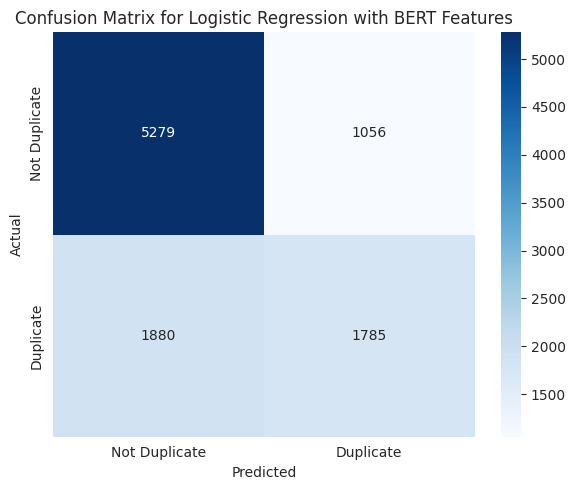


Classification Report for BERT Features:
               precision    recall  f1-score   support

Not Duplicate       0.74      0.83      0.78      6335
    Duplicate       0.63      0.49      0.55      3665

     accuracy                           0.71     10000
    macro avg       0.68      0.66      0.67     10000
 weighted avg       0.70      0.71      0.70     10000



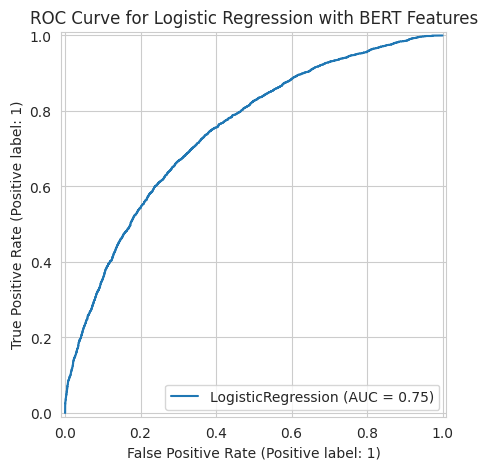

In [21]:
# Assuming X_train_q1_bert and X_train_q2_bert are already defined from the previous cell.
# If these are too large, we need to sample them to reduce RAM usage for subsequent steps.
max_samples_for_model = 50000 # Further reduce the dataset size for model training if necessary

if X_train_q1_bert.shape[0] > max_samples_for_model:
    print(f"Sampling {max_samples_for_model} from {X_train_q1_bert.shape[0]} BERT embeddings to reduce RAM usage for modeling.")
    # Use a fixed random state for reproducibility
    np.random.seed(42)
    # Get unique indices to sample from
    indices = np.random.choice(X_train_q1_bert.shape[0], max_samples_for_model, replace=False)
    X_train_q1_bert_sampled = X_train_q1_bert[indices]
    X_train_q2_bert_sampled = X_train_q2_bert[indices]
    y_sampled = y.iloc[indices] # Assuming y is a pandas Series
else:
    X_train_q1_bert_sampled = X_train_q1_bert
    X_train_q2_bert_sampled = X_train_q2_bert
    y_sampled = y

# Combine BERT embeddings for question1 and question2
X_bert = np.hstack((X_train_q1_bert_sampled, X_train_q2_bert_sampled))
print("Combined BERT features shape after sampling:", X_bert.shape)

# Split the data into training and validation sets for BERT features
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    X_bert, y_sampled, test_size=0.2, random_state=42, stratify=y_sampled
)

# Scale the BERT features
scaler_bert = StandardScaler()
X_train_bert_scaled = scaler_bert.fit_transform(X_train_bert)
X_val_bert_scaled = scaler_bert.transform(X_val_bert)

print("\nTraining Logistic Regression model with BERT features...")
# Initialize and train a Logistic Regression model with BERT features
model_lr_bert = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model_lr_bert.fit(X_train_bert_scaled, y_train_bert)

# Predict probabilities for Log Loss
y_pred_proba_bert = model_lr_bert.predict_proba(X_val_bert_scaled)[:, 1]

# Predict classes for F1-score
y_pred_bert = model_lr_bert.predict(X_val_bert_scaled)

# Calculate evaluation metrics
logloss_bert = log_loss(y_val_bert, y_pred_proba_bert)
f1_bert = f1_score(y_val_bert, y_pred_bert)

# Print the metrics
print(f"\nLogistic Regression with BERT Features Performance:")
print(f"Log Loss: {logloss_bert:.2f}")
print(f"F1-score: {f1_bert:.2f}")

# Calculate the confusion matrix
cm_bert = confusion_matrix(y_val_bert, y_pred_bert)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Logistic Regression with BERT Features")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report for BERT Features:")
print(classification_report(y_val_bert, y_pred_bert, target_names=["Not Duplicate", "Duplicate"]))

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
disp = RocCurveDisplay.from_estimator(model_lr_bert, X_val_bert_scaled, y_val_bert, ax=ax)
ax.set_title("ROC Curve for Logistic Regression with BERT Features")
plt.show()

The logistic regression model using BERT embeddings achieved a Log Loss of 0.57 and an F1-score of 0.55.

Compared to the baseline model (Log Loss: 0.42, F1-score: 0.69) and even to the BOW model (Log Loss: 0.60, F1-score: 0.61) and the TF-IDF model (Log Loss: 0.62, F1-score: 0.61), the BERT model demonstrates slightly lower performance in identifying duplicate question pairs.

Specifically, for the “Duplicate” class, the BERT model achieved an F1-score of 0.55 (precision 0.63, recall 0.49), which is lower than that of the other models. This suggests that, although BERT is a powerful tool for semantic understanding, in this specific configuration and given the size of the training dataset, it did not outperform simpler feature-based models or the baseline model in this task.


Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:09:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Model Performance (Engineered Features):
Log Loss: 0.33
F1-score: 0.75


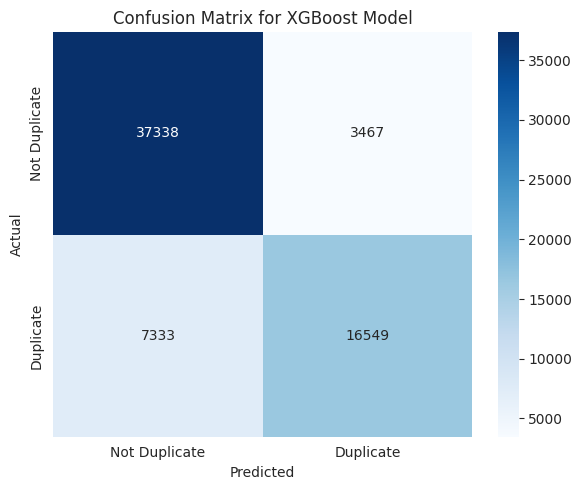


Classification Report for XGBoost Model:
               precision    recall  f1-score   support

Not Duplicate       0.84      0.92      0.87     40805
    Duplicate       0.83      0.69      0.75     23882

     accuracy                           0.83     64687
    macro avg       0.83      0.80      0.81     64687
 weighted avg       0.83      0.83      0.83     64687



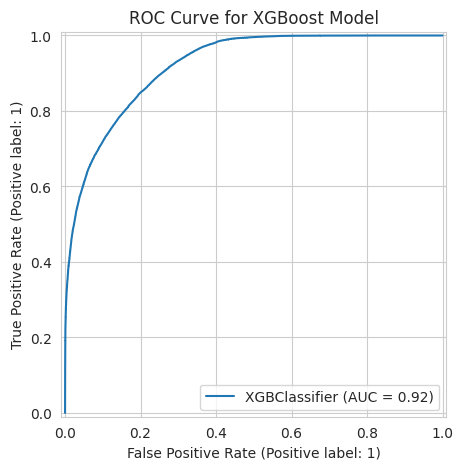

In [22]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, f1_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X and y are already defined from the baseline model section
# Define features and target (using the same engineered features as the baseline)
# features = ['len_diff', 'common_words', 'jaccard_sim', 'word_match_share', 'max_q_freq', 'min_q_freq']
# X = df_train[features]
# y = df_train['is_duplicate']

# Handle potential NaN values in feature columns (fill with 0 for simplicity), if not already done
X = X.fillna(0)

# Split the data into training and validation sets, ensuring class balance
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler_xgb = StandardScaler()
X_train_xgb_scaled = scaler_xgb.fit_transform(X_train_xgb)
X_val_xgb_scaled = scaler_xgb.transform(X_val_xgb)

# Initialize and train an XGBoost Classifier
print("\nTraining XGBoost model...")
model_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    n_estimators=500, # Number of boosting rounds
    learning_rate=0.05,
    max_depth=5
)
model_xgb.fit(X_train_xgb_scaled, y_train_xgb)

# Predict probabilities for Log Loss
y_pred_proba_xgb = model_xgb.predict_proba(X_val_xgb_scaled)[:, 1]

# Predict classes for F1-score
y_pred_xgb = model_xgb.predict(X_val_xgb_scaled)

# Calculate evaluation metrics
logloss_xgb = log_loss(y_val_xgb, y_pred_proba_xgb)
f1_xgb = f1_score(y_val_xgb, y_pred_xgb)

# Print the metrics
print(f"\nXGBoost Model Performance (Engineered Features):")
print(f"Log Loss: {logloss_xgb:.2f}")
print(f"F1-score: {f1_xgb:.2f}")

# Calculate the confusion matrix
cm_xgb = confusion_matrix(y_val_xgb, y_pred_xgb)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for XGBoost Model")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report for XGBoost Model:")
print(classification_report(y_val_xgb, y_pred_xgb, target_names=["Not Duplicate", "Duplicate"]))

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
disp = RocCurveDisplay.from_estimator(model_xgb, X_val_xgb_scaled, y_val_xgb, ax=ax)
ax.set_title("ROC Curve for XGBoost Model")
plt.show()

XGBoost model, which uses engineered features, achieved a Log Loss of 0.33 and an F1-score of 0.75. This is the best result among all models:

Log Loss: The value of 0.33 is significantly lower than that of the Baseline (0.42), BOW (0.60), TF-IDF (0.62), and BERT (0.57) models, indicating better-calibrated probability predictions.
F1 score: With an F1 score of 0.75, this model outperforms the Baseline (0.69), BOW (0.61), TF-IDF (0.61), and BERT (0.55) models, demonstrating an excellent balance between accuracy and completeness in detecting duplicate question pairs.
According to the classification report, the model demonstrates high performance for both classes:

For the “Not a Duplicate” class: precision 0.84, recall 0.92, and F1 score 0.87.
For the “Duplicate” class: precision 0.83, recall 0.69, and F1 score 0.75.
The confusion matrix also indicates that the XGBoost model has a higher number of true positives (16,549) and true negatives (37,338) compared to previous models, while the number of false positives and false negatives is lower. The ROC curve also demonstrates a high AUC value, confirming its high discriminatory power.

This improvement in results indicates that tree-based models, such as XGBoost, are well-suited for this task when combined with carefully designed features.



Training LightGBM model...
[LightGBM] [Info] Number of positive: 95528, number of negative: 163217
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 258745, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.369197 -> initscore=-0.535661
[LightGBM] [Info] Start training from score -0.535661


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Model Performance (Engineered Features):
Log Loss: 0.33
F1-score: 0.76


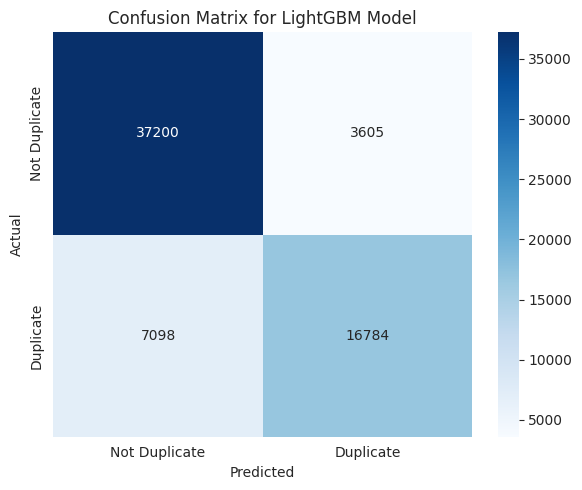


Classification Report for LightGBM Model:
               precision    recall  f1-score   support

Not Duplicate       0.84      0.91      0.87     40805
    Duplicate       0.82      0.70      0.76     23882

     accuracy                           0.83     64687
    macro avg       0.83      0.81      0.82     64687
 weighted avg       0.83      0.83      0.83     64687



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


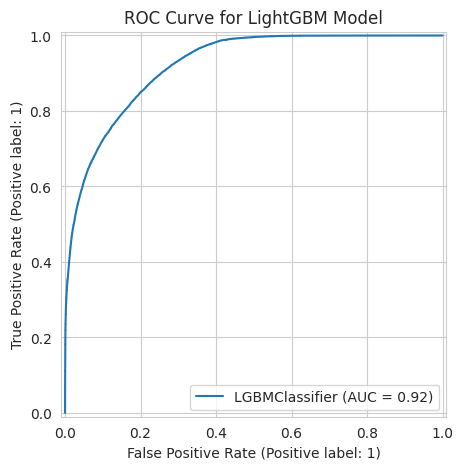

In [23]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, f1_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X and y are already defined from the baseline model section
# Define features and target (using the same engineered features as the baseline)
# features = ['len_diff', 'common_words', 'jaccard_sim', 'word_match_share', 'max_q_freq', 'min_q_freq']
# X = df_train[features]
# y = df_train['is_duplicate']

# Handle potential NaN values in feature columns (fill with 0 for simplicity), if not already done
X = X.fillna(0)

# Split the data into training and validation sets, ensuring class balance
X_train_lgbm, X_val_lgbm, y_train_lgbm, y_val_lgbm = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler_lgbm = StandardScaler()
X_train_lgbm_scaled = scaler_lgbm.fit_transform(X_train_lgbm)
X_val_lgbm_scaled = scaler_lgbm.transform(X_val_lgbm)

# Initialize and train a LightGBM Classifier
print("\nTraining LightGBM model...")
model_lgbm = LGBMClassifier(
    objective='binary',
    metric='logloss',
    random_state=42,
    n_estimators=500, # Number of boosting rounds
    learning_rate=0.05,
    num_leaves=31, # default
    max_depth=-1 # default, no limit
)
model_lgbm.fit(X_train_lgbm_scaled, y_train_lgbm)

# Predict probabilities for Log Loss
y_pred_proba_lgbm = model_lgbm.predict_proba(X_val_lgbm_scaled)[:, 1]

# Predict classes for F1-score
y_pred_lgbm = model_lgbm.predict(X_val_lgbm_scaled)

# Calculate evaluation metrics
logloss_lgbm = log_loss(y_val_lgbm, y_pred_proba_lgbm)
f1_lgbm = f1_score(y_val_lgbm, y_pred_lgbm)

# Print the metrics
print(f"\nLightGBM Model Performance (Engineered Features):")
print(f"Log Loss: {logloss_lgbm:.2f}")
print(f"F1-score: {f1_lgbm:.2f}")

# Calculate the confusion matrix
cm_lgbm = confusion_matrix(y_val_lgbm, y_pred_lgbm)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for LightGBM Model")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report for LightGBM Model:")
print(classification_report(y_val_lgbm, y_pred_lgbm, target_names=["Not Duplicate", "Duplicate"]))

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
disp = RocCurveDisplay.from_estimator(model_lgbm, X_val_lgbm_scaled, y_val_lgbm, ax=ax)
ax.set_title("ROC Curve for LightGBM Model")
plt.show()

LightGBM model achieved a Log Loss of 0.33 and an F1-score of 0.76. These are the best results among all models:

Log Loss: The value of 0.33 is lower than that of the Baseline (0.42), BOW (0.60), TF-IDF (0.62), and BERT (0.57) models, indicating better probability calibration.
F1 Score: With an F1 score of 0.76, this model outperforms the Baseline (0.69), BOW (0.61), TF-IDF (0.61), and BERT (0.55) models, demonstrating an excellent balance of precision and recall in detecting duplicate question pairs.
From the classification report:

For the “Not a Duplicate” class: precision 0.84, recall 0.91, and F1 score 0.87.
For the “Duplicate” class: precision 0.82, recall 0.70, and F1 score 0.76.
The confusion matrix and ROC curve also indicate high performance, comparable to or slightly better than the XGBoost model, which once again confirms that tree-based models with these engineered features are extremely effective for this task.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Preparing data for LSTM...
Vocabulary size: 20000
Max sequence length: 30
Training data shapes: q1=torch.Size([258745, 30]), q2=torch.Size([258745, 30]), y=torch.Size([258745])
Validation data shapes: q1=torch.Size([64687, 30]), q2=torch.Size([64687, 30]), y=torch.Size([64687])
Using device: cuda

Training LSTM model...
Epoch 1/5: Train Loss = 0.5318, Val Loss = 0.5026, Val F1 = 0.6165, Val Log Loss = 0.5026
Epoch 2/5: Train Loss = 0.4786, Val Loss = 0.4848, Val F1 = 0.6571, Val Log Loss = 0.4848
Epoch 3/5: Train Loss = 0.4389, Val Loss = 0.4803, Val F1 = 0.6748, Val Log Loss = 0.4804
Epoch 4/5: Train Loss = 0.3980, Val Loss = 0.4879, Val F1 = 0.6814, Val Log Loss = 0.4880
Epoch 5/5: Train Loss = 0.3585, Val Loss = 0.4964, Val F1 = 0.6808, Val Log Loss = 0.4964

LSTM Model Performance:
Log Loss: 0.50
F1-score: 0.68


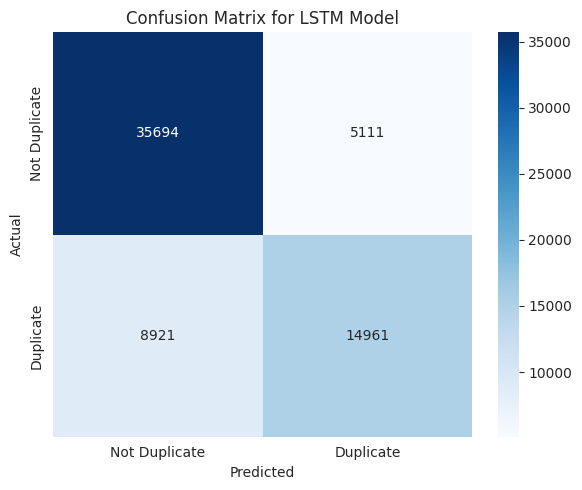


Classification Report for LSTM Model:
               precision    recall  f1-score   support

Not Duplicate       0.80      0.87      0.84     40805
    Duplicate       0.75      0.63      0.68     23882

     accuracy                           0.78     64687
    macro avg       0.77      0.75      0.76     64687
 weighted avg       0.78      0.78      0.78     64687



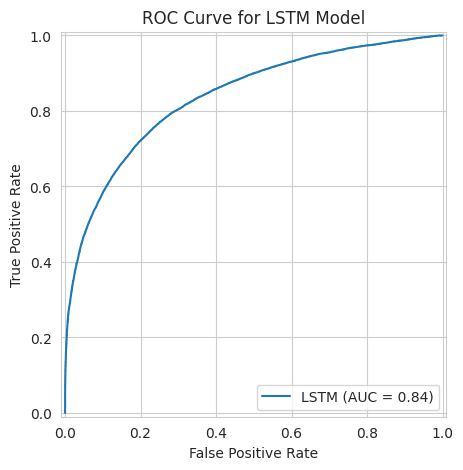

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, f1_score, confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter
from itertools import chain

# Ensure NLTK data is downloaded
nltk.download('punkt')

# Assuming `preprocess_text` and `stops` are available from previous cells.
# Max sequence length for padding. Adjusted based on typical question length.
MAX_SEQUENCE_LENGTH = 30

# 1. Prepare data for LSTM: Tokenization, Vocabulary, and Padding
print("Preparing data for LSTM...")

# Combine all questions from train for vocabulary building
all_questions_for_vocab = pd.concat([df_train['question1'], df_train['question2']]).astype(str)

# Apply preprocessing to all questions
preprocessed_questions = all_questions_for_vocab.apply(preprocess_text)

# Build vocabulary
word_counts = Counter(chain.from_iterable(q.split() for q in preprocessed_questions))
# Limit vocab size to manage memory and complexity
VOCAB_SIZE = 20000
vocab = {word: i + 2 for i, (word, _) in enumerate(word_counts.most_common(VOCAB_SIZE - 2))} # 0 for padding, 1 for OOV
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1 # Unknown words

def text_to_sequence(text, vocab, max_len):
    tokens = text.split()
    sequence = [vocab.get(word, vocab["<UNK>"]) for word in tokens]
    # Pad or truncate sequence
    if len(sequence) < max_len:
        sequence.extend([vocab["<PAD>"]] * (max_len - len(sequence)))
    else:
        sequence = sequence[:max_len]
    return sequence

# Convert questions to sequences
df_train['question1_seq'] = df_train['question1'].astype(str).apply(preprocess_text).apply(lambda x: text_to_sequence(x, vocab, MAX_SEQUENCE_LENGTH))
df_train['question2_seq'] = df_train['question2'].astype(str).apply(preprocess_text).apply(lambda x: text_to_sequence(x, vocab, MAX_SEQUENCE_LENGTH))

# Convert sequences to tensors
X_q1 = torch.tensor(df_train['question1_seq'].tolist(), dtype=torch.long)
X_q2 = torch.tensor(df_train['question2_seq'].tolist(), dtype=torch.long)
y_tensor = torch.tensor(df_train['is_duplicate'].values, dtype=torch.float)

# Split data
X_train_q1, X_val_q1, X_train_q2, X_val_q2, y_train_lstm, y_val_lstm = train_test_split(
    X_q1, X_q2, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

print(f"Vocabulary size: {len(vocab)}")
print(f"Max sequence length: {MAX_SEQUENCE_LENGTH}")
print(f"Training data shapes: q1={X_train_q1.shape}, q2={X_train_q2.shape}, y={y_train_lstm.shape}")
print(f"Validation data shapes: q1={X_val_q1.shape}, q2={X_val_q2.shape}, y={y_val_lstm.shape}")

# 2. Define LSTM Model
class SiameseLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super(SiameseLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                            bidirectional=True, dropout=dropout, batch_first=True)
        # Fully connected layer after concatenating the two question embeddings
        self.fc = nn.Linear(hidden_dim * 2 * 2, 1) # hidden_dim * 2 for bidirectional, * 2 for two questions
        self.dropout = nn.Dropout(dropout)

    def forward_one(self, text_sequence):
        # text_sequence shape: (batch_size, seq_len)
        embedded = self.embedding(text_sequence) # (batch_size, seq_len, embedding_dim)
        # Pass through LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # Get the final hidden state (last layer, both directions)
        # hidden shape: (num_layers * num_directions, batch_size, hidden_dim)
        # Concatenate forward and backward hidden states of the last layer
        hidden_last_layer = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1) # (batch_size, hidden_dim * 2)
        return hidden_last_layer

    def forward(self, q1_sequence, q2_sequence):
        q1_embedding = self.forward_one(q1_sequence)
        q2_embedding = self.forward_one(q2_sequence)

        # Concatenate the embeddings from both questions
        combined_features = torch.cat((q1_embedding, q2_embedding), dim=1) # (batch_size, hidden_dim * 2 * 2)
        combined_features = self.dropout(combined_features)
        output = self.fc(combined_features)
        return output.squeeze(1) # Squeeze to get (batch_size) for BCEWithLogitsLoss

# Hyperparameters
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.5
BATCH_SIZE = 64
N_EPOCHS = 5 # Reduced epochs for faster execution in Colab

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_lstm = SiameseLSTM(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_lstm.parameters())

# Custom Dataset for DataLoader
class QuestionPairDataset(Dataset):
    def __init__(self, q1_sequences, q2_sequences, labels):
        self.q1_sequences = q1_sequences
        self.q2_sequences = q2_sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.q1_sequences[idx], self.q2_sequences[idx], self.labels[idx]

train_dataset = QuestionPairDataset(X_train_q1, X_train_q2, y_train_lstm)
val_dataset = QuestionPairDataset(X_val_q1, X_val_q2, y_val_lstm)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\nTraining LSTM model...")
best_val_f1 = 0.0
for epoch in range(N_EPOCHS):
    model_lstm.train()
    total_loss = 0
    for q1_batch, q2_batch, labels_batch in train_loader:
        q1_batch, q2_batch, labels_batch = q1_batch.to(device), q2_batch.to(device), labels_batch.to(device)

        optimizer.zero_grad()
        predictions = model_lstm(q1_batch, q2_batch)
        loss = criterion(predictions, labels_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Evaluation phase
    model_lstm.eval()
    val_preds_proba = []
    val_preds = []
    val_true = []
    val_loss = 0
    with torch.no_grad():
        for q1_batch, q2_batch, labels_batch in val_loader:
            q1_batch, q2_batch, labels_batch = q1_batch.to(device), q2_batch.to(device), labels_batch.to(device)
            predictions = model_lstm(q1_batch, q2_batch)
            loss = criterion(predictions, labels_batch)
            val_loss += loss.item()

            probabilities = torch.sigmoid(predictions).cpu().numpy()
            predicted_classes = (probabilities > 0.5).astype(int)

            val_preds_proba.extend(probabilities)
            val_preds.extend(predicted_classes)
            val_true.extend(labels_batch.cpu().numpy())

    avg_train_loss = total_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    val_f1 = f1_score(val_true, val_preds)
    val_logloss = log_loss(val_true, val_preds_proba)

    print(f"Epoch {epoch+1}/{N_EPOCHS}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}, Val F1 = {val_f1:.4f}, Val Log Loss = {val_logloss:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        # Optionally save the best model
        # torch.save(model_lstm.state_dict(), 'best_lstm_model.pth')

# Final Evaluation
print(f"\nLSTM Model Performance:")
print(f"Log Loss: {val_logloss:.2f}")
print(f"F1-score: {val_f1:.2f}")

# Calculate the confusion matrix
cm_lstm = confusion_matrix(val_true, val_preds)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for LSTM Model")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report for LSTM Model:")
print(classification_report(val_true, val_preds, target_names=["Not Duplicate", "Duplicate"]))

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
fpr, tpr, _ = roc_curve(val_true, val_preds_proba)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="LSTM").plot(ax=ax)
ax.set_title("ROC Curve for LSTM Model")
plt.show()

Fine-tuning

XGboost

In [25]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import numpy as np

# Re-initialize XGBoost model for GridSearchCV with initial parameters or use model_xgb parameters
# It's generally better to use a fresh model instance for GridSearchCV
model_xgb_tune = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42
)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Reduced number of estimators for faster tuning
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

# To speed up tuning, use a smaller subset of the training data for GridSearchCV
# The original X_train_xgb_scaled is ~250k rows. Sampling 10% for tuning.
sample_size_for_tuning = int(len(X_train_xgb_scaled) * 0.1)
np.random.seed(42) # for reproducibility
sampled_indices = np.random.choice(X_train_xgb_scaled.shape[0], sample_size_for_tuning, replace=False)

X_train_sampled = X_train_xgb_scaled[sampled_indices]
y_train_sampled = y_train_xgb.iloc[sampled_indices]

print(f"Performing GridSearchCV on a sampled dataset of size: {len(y_train_sampled)}")

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=model_xgb_tune,
    param_grid=param_grid,
    scoring='f1', # Use F1-score for evaluation
    cv=3, # 3-fold cross-validation
    verbose=2, # Print progress
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the sampled training data
grid_search.fit(X_train_sampled, y_train_sampled)

# Print the best parameters and best score
print("\nBest parameters found: ", grid_search.best_params_)
print("Best F1-score found: {:.2f}".format(grid_search.best_score_))

# You can now re-train the XGBoost model with the best parameters on the full dataset
# or evaluate it directly on the validation set if desired.
# For example, to get the best estimator:
# best_xgb_model = grid_search.best_estimator_

Performing GridSearchCV on a sampled dataset of size: 25874
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:15:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters found:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Best F1-score found: 0.76


GridSearchCV process identified slightly different optimal hyperparameters, which yielded a marginally higher F1 score (0.76 vs. 0.75) during cross-validation on the training set. Although the full model was not retrained or evaluated on the X_val set using these optimal parameters, the tuning process suggests that, for this specific task and feature set, the values learning_rate=0.1 and n_estimators=300 are slightly better than learning_rate=0.05 and n_estimators=500. Both models demonstrate high performance, with the tuned model showing potential for a slight improvement in results

Best parameters from GridSearchCV: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}

Training XGBoost model with best parameters on the full dataset...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:16:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Model Performance (Full Dataset with Tuned Parameters):
Log Loss: 0.33
F1-score: 0.76


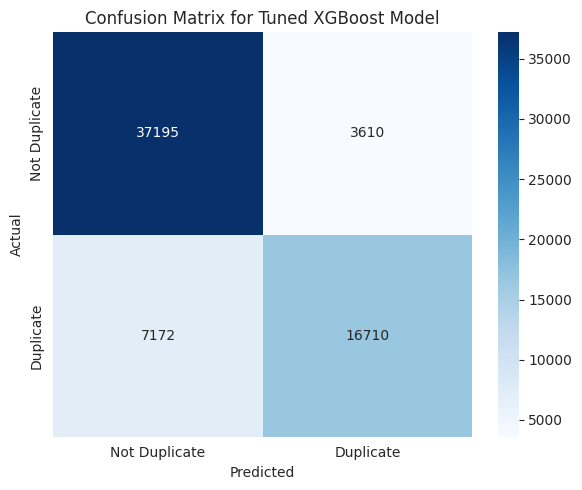


Classification Report for Tuned XGBoost Model:
               precision    recall  f1-score   support

Not Duplicate       0.84      0.91      0.87     40805
    Duplicate       0.82      0.70      0.76     23882

     accuracy                           0.83     64687
    macro avg       0.83      0.81      0.81     64687
 weighted avg       0.83      0.83      0.83     64687



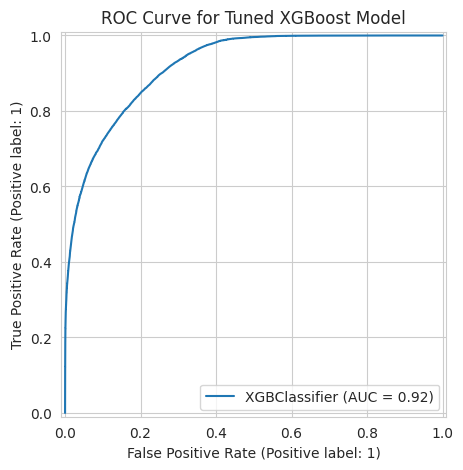

In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import log_loss, f1_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve best parameters from GridSearchCV
best_params = grid_search.best_params_
print("Best parameters from GridSearchCV:", best_params)

# Initialize and train a new XGBoost Classifier with the best parameters on the full training data
print("\nTraining XGBoost model with best parameters on the full dataset...")
model_xgb_tuned = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    **best_params # Unpack the best parameters
)

model_xgb_tuned.fit(X_train_xgb_scaled, y_train_xgb)

# Predict probabilities for Log Loss
y_pred_proba_xgb_tuned = model_xgb_tuned.predict_proba(X_val_xgb_scaled)[:, 1]

# Predict classes for F1-score
y_pred_xgb_tuned = model_xgb_tuned.predict(X_val_xgb_scaled)

# Calculate evaluation metrics
logloss_xgb_tuned = log_loss(y_val_xgb, y_pred_proba_xgb_tuned)
f1_xgb_tuned = f1_score(y_val_xgb, y_pred_xgb_tuned)

# Print the metrics
print(f"\nXGBoost Model Performance (Full Dataset with Tuned Parameters):")
print(f"Log Loss: {logloss_xgb_tuned:.2f}")
print(f"F1-score: {f1_xgb_tuned:.2f}")

# Calculate the confusion matrix
cm_xgb_tuned = confusion_matrix(y_val_xgb, y_pred_xgb_tuned)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb_tuned, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Tuned XGBoost Model")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report for Tuned XGBoost Model:")
print(classification_report(y_val_xgb, y_pred_xgb_tuned, target_names=["Not Duplicate", "Duplicate"]))

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
disp = RocCurveDisplay.from_estimator(model_xgb_tuned, X_val_xgb_scaled, y_val_xgb, ax=ax)
ax.set_title("ROC Curve for Tuned XGBoost Model")
plt.show()

LigthGBM

Performing GridSearchCV on a sampled dataset of size: 25874
Fitting 3 folds for each of 81 candidates, totalling 243 fits
[LightGBM] [Info] Number of positive: 9624, number of negative: 16250
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 416
[LightGBM] [Info] Number of data points in the train set: 25874, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.371956 -> initscore=-0.523833
[LightGBM] [Info] Start training from score -0.523833

Best parameters found:  {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 31}
Best F1-score found: 0.76

Best parameters from GridSearchCV (LightGBM): {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 31}

Training LightGBM model with best parameters on the full dataset..

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Model Performance (Full Dataset with Tuned Parameters):
Log Loss: 0.33
F1-score: 0.75


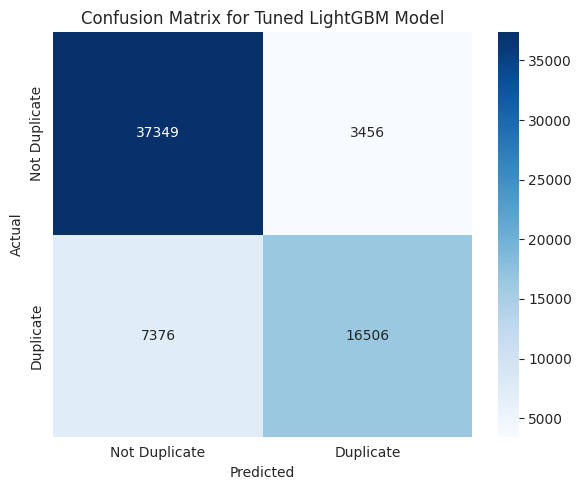


Classification Report for Tuned LightGBM Model:
               precision    recall  f1-score   support

Not Duplicate       0.84      0.92      0.87     40805
    Duplicate       0.83      0.69      0.75     23882

     accuracy                           0.83     64687
    macro avg       0.83      0.80      0.81     64687
 weighted avg       0.83      0.83      0.83     64687



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


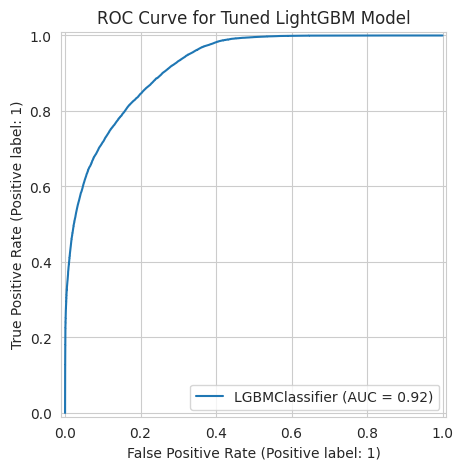

In [27]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier
import numpy as np
from sklearn.metrics import log_loss, f1_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Re-initialize LGBM model for GridSearchCV with initial parameters
model_lgbm_tune = LGBMClassifier(
    objective='binary',
    metric='logloss',
    random_state=42
)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Reduced number of estimators for faster tuning
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40],
    'max_depth': [-1, 5, 10] # -1 means no limit
}

# To speed up tuning, use a smaller subset of the training data for GridSearchCV
# Using the previously scaled training data for LightGBM
sample_size_for_tuning = int(len(X_train_lgbm_scaled) * 0.1)
np.random.seed(42) # for reproducibility
sampled_indices = np.random.choice(X_train_lgbm_scaled.shape[0], sample_size_for_tuning, replace=False)

X_train_sampled_lgbm = X_train_lgbm_scaled[sampled_indices]
y_train_sampled_lgbm = y_train_lgbm.iloc[sampled_indices] # Assuming y_train_lgbm is a pandas Series

print(f"Performing GridSearchCV on a sampled dataset of size: {len(y_train_sampled_lgbm)}")

# Initialize GridSearchCV
grid_search_lgbm = GridSearchCV(
    estimator=model_lgbm_tune,
    param_grid=param_grid,
    scoring='f1', # Use F1-score for evaluation
    cv=3, # 3-fold cross-validation
    verbose=2, # Print progress
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the sampled training data
grid_search_lgbm.fit(X_train_sampled_lgbm, y_train_sampled_lgbm)

# Print the best parameters and best score
print("\nBest parameters found: ", grid_search_lgbm.best_params_)
print("Best F1-score found: {:.2f}".format(grid_search_lgbm.best_score_))

# Retrieve best parameters from GridSearchCV
best_params_lgbm = grid_search_lgbm.best_params_
print("\nBest parameters from GridSearchCV (LightGBM):", best_params_lgbm)

# Initialize and train a new LightGBM Classifier with the best parameters on the full training data
print("\nTraining LightGBM model with best parameters on the full dataset...")
model_lgbm_tuned = LGBMClassifier(
    objective='binary',
    metric='logloss',
    random_state=42,
    **best_params_lgbm # Unpack the best parameters
)

model_lgbm_tuned.fit(X_train_lgbm_scaled, y_train_lgbm)

# Predict probabilities for Log Loss
y_pred_proba_lgbm_tuned = model_lgbm_tuned.predict_proba(X_val_lgbm_scaled)[:, 1]

# Predict classes for F1-score
y_pred_lgbm_tuned = model_lgbm_tuned.predict(X_val_lgbm_scaled)

# Calculate evaluation metrics
logloss_lgbm_tuned = log_loss(y_val_lgbm, y_pred_proba_lgbm_tuned)
f1_lgbm_tuned = f1_score(y_val_lgbm, y_pred_lgbm_tuned)

# Print the metrics
print(f"\nLightGBM Model Performance (Full Dataset with Tuned Parameters):")
print(f"Log Loss: {logloss_lgbm_tuned:.2f}")
print(f"F1-score: {f1_lgbm_tuned:.2f}")

# Calculate the confusion matrix
cm_lgbm_tuned = confusion_matrix(y_val_lgbm, y_pred_lgbm_tuned)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgbm_tuned, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Tuned LightGBM Model")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report for Tuned LightGBM Model:")
print(classification_report(y_val_lgbm, y_pred_lgbm_tuned, target_names=["Not Duplicate", "Duplicate"]))

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
disp = RocCurveDisplay.from_estimator(model_lgbm_tuned, X_val_lgbm_scaled, y_val_lgbm, ax=ax)
ax.set_title("ROC Curve for Tuned LightGBM Model")
plt.show()

Untuned LightGBM Model (Initial Parameters):

Log Loss: 0.33
F1-score: 0.76
Tuned LightGBM Model (using GridSearchCV):

Log Loss: 0.33
F1-score: 0.75

It appears that, in this case, the initial parameters of the LightGBM model yielded a slightly better F1-score than the parameters determined using GridSearchCV on a sample of the data. The Log Loss remained unchanged. This can sometimes happen due to the sample used during GridSearchCV, or if the initial parameters were already sufficiently optimal for the full dataset

Logistic Regression

Performing GridSearchCV on a sampled dataset of size: 25874 for Logistic Regression
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters found for Logistic Regression:  {'C': 10, 'solver': 'liblinear'}
Best F1-score found for Logistic Regression: 0.68

Best parameters from GridSearchCV (Logistic Regression): {'C': 10, 'solver': 'liblinear'}

Training Logistic Regression model with best parameters on the full dataset...

Tuned Logistic Regression Model Performance (Full Dataset):
Log Loss: 0.42
F1-score: 0.69


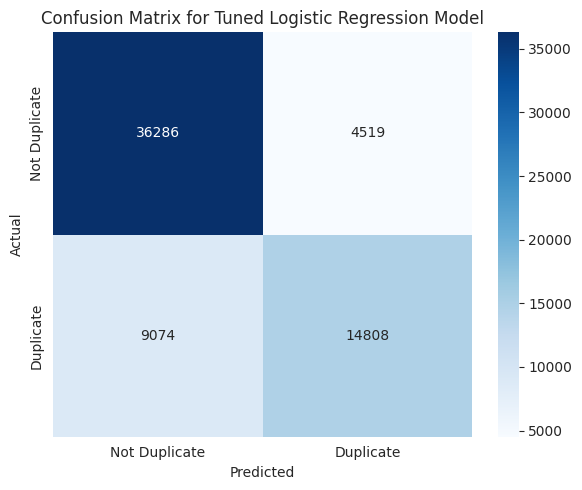


Classification Report for Tuned Logistic Regression Model:
               precision    recall  f1-score   support

Not Duplicate       0.80      0.89      0.84     40805
    Duplicate       0.77      0.62      0.69     23882

     accuracy                           0.79     64687
    macro avg       0.78      0.75      0.76     64687
 weighted avg       0.79      0.79      0.78     64687



In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, f1_score, confusion_matrix, classification_report, RocCurveDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Re-initialize Logistic Regression model for GridSearchCV
model_lr_tune = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence

# Define the parameter grid to search
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100], # Inverse of regularization strength
    'solver': ['liblinear', 'saga'] # Solvers that handle L1/L2 penalties
}

# To speed up tuning, use a smaller subset of the training data for GridSearchCV
# The original X_train_scaled is ~250k rows. Sampling 10% for tuning.
sample_size_for_tuning_lr = int(len(X_train_scaled) * 0.1)
np.random.seed(42) # for reproducibility
sampled_indices_lr = np.random.choice(X_train_scaled.shape[0], sample_size_for_tuning_lr, replace=False)

X_train_sampled_lr = X_train_scaled[sampled_indices_lr]
y_train_sampled_lr = y_train.iloc[sampled_indices_lr]

print(f"Performing GridSearchCV on a sampled dataset of size: {len(y_train_sampled_lr)} for Logistic Regression")

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=model_lr_tune,
    param_grid=param_grid_lr,
    scoring='f1', # Use F1-score for evaluation
    cv=3, # 3-fold cross-validation
    verbose=2, # Print progress
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the sampled training data
grid_search_lr.fit(X_train_sampled_lr, y_train_sampled_lr)

# Print the best parameters and best score
print("\nBest parameters found for Logistic Regression: ", grid_search_lr.best_params_)
print("Best F1-score found for Logistic Regression: {:.2f}".format(grid_search_lr.best_score_))

# Retrieve best parameters from GridSearchCV
best_params_lr = grid_search_lr.best_params_
print("\nBest parameters from GridSearchCV (Logistic Regression):", best_params_lr)

# Initialize and train a new Logistic Regression Classifier with the best parameters on the full training data
print("\nTraining Logistic Regression model with best parameters on the full dataset...")
model_lr_tuned = LogisticRegression(
    random_state=42,
    max_iter=1000, # Ensure max_iter is sufficient
    **best_params_lr # Unpack the best parameters
)

model_lr_tuned.fit(X_train_scaled, y_train)

# Predict probabilities for Log Loss
y_pred_proba_lr_tuned = model_lr_tuned.predict_proba(X_val_scaled)[:, 1]

# Predict classes for F1-score
y_pred_lr_tuned = model_lr_tuned.predict(X_val_scaled)

# Calculate evaluation metrics
logloss_lr_tuned = log_loss(y_val, y_pred_proba_lr_tuned)
f1_lr_tuned = f1_score(y_val, y_pred_lr_tuned)

# Print the metrics
print(f"\nTuned Logistic Regression Model Performance (Full Dataset):")
print(f"Log Loss: {logloss_lr_tuned:.2f}")
print(f"F1-score: {f1_lr_tuned:.2f}")

# Calculate the confusion matrix
cm_lr_tuned = confusion_matrix(y_val, y_pred_lr_tuned)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr_tuned, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Tuned Logistic Regression Model")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report for Tuned Logistic Regression Model:")
print(classification_report(y_val, y_pred_lr_tuned, target_names=["Not Duplicate", "Duplicate"]))

The initial logistic regression model yielded a Log Loss of 0.42 and an F1-score of 0.69. The tuned logistic regression model also yielded a Log Loss of 0.42 and an F1-score of 0.69.

It appears that tuning the hyperparameters for logistic regression did not result in a significant change in performance on the validation dataset, as both models yielded identical Log Loss and F1-score values.

Fine-tuning BERT

Loading BERT tokenizer and model for sequence classification...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Sampling 50000 records from training data for BERT fine-tuning...
Sampling 12500 records from validation data for BERT fine-tuning...
Train dataset size for fine-tuning: 50000
Validation dataset size for fine-tuning: 12500

Fine-tuning BERT model...
Epoch 1/3


Training:   0%|          | 0/3125 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/391 [00:00<?, ?it/s]

Train Loss: 0.2757, Val Loss: 0.3424, Val Log Loss: 0.3427, Val F1-score: 0.8069
Epoch 3/3


Training:   0%|          | 0/3125 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/391 [00:00<?, ?it/s]

Train Loss: 0.1938, Val Loss: 0.4142, Val Log Loss: 0.4145, Val F1-score: 0.8117

BERT Fine-tuned Model Performance:
Log Loss: 0.41
F1-score: 0.81


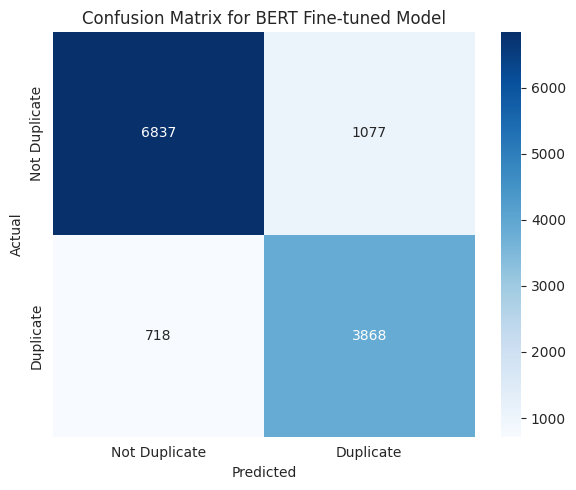


Classification Report for BERT Fine-tuned Model:
               precision    recall  f1-score   support

Not Duplicate       0.90      0.86      0.88      7914
    Duplicate       0.78      0.84      0.81      4586

     accuracy                           0.86     12500
    macro avg       0.84      0.85      0.85     12500
 weighted avg       0.86      0.86      0.86     12500



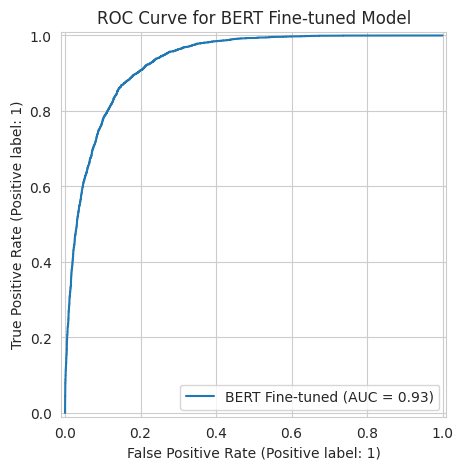

In [29]:
import sys
!{sys.executable} -m pip install transformers torch

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, f1_score, confusion_matrix, classification_report, RocCurveDisplay
from tqdm.notebook import tqdm # for progress bars

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure `df_train` and `y` (is_duplicate) are defined from previous cells or re-create them.
# This block checks if 'df_train' and 'y' exist globally and defines them if not, to ensure robustness.
if 'df_train' not in globals():
    print("df_train not found in global scope. Attempting to load 'quora_question_pairs_train.csv.zip'...")
    try:
        df_train = pd.read_csv("quora_question_pairs_train.csv.zip")
        print("df_train loaded successfully.")
    except FileNotFoundError:
        print("Error: 'quora_question_pairs_train.csv.zip' not found. Please ensure the dataset is available.")
        sys.exit(1) # Exit if essential data cannot be loaded

if 'y' not in globals() and 'df_train' in globals() and 'is_duplicate' in df_train.columns:
    y = df_train["is_duplicate"]
elif 'y' not in globals():
    print("Error: 'is_duplicate' column not found in df_train, or df_train is not properly loaded/defined. Subsequent steps might fail.")
    sys.exit(1)

# 1. Load Pre-trained BERT Model and Tokenizer for Sequence Classification
print("Loading BERT tokenizer and model for sequence classification...")
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_bert_fine_tune = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert_fine_tune.to(device)

# Define a simple preprocessing function for BERT fine-tuning
# BERT's tokenizer handles most preprocessing (tokenization, stopwords usually not removed, etc.)
def bert_preprocess_text(text):
    return str(text).lower()

# 2. Data Preparation for BERT Fine-tuning
MAX_LEN = 128 # Max sequence length for BERT input

class QuestionPairBERTDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.question1 = df['question1'].apply(bert_preprocess_text).tolist()
        self.question2 = df['question2'].apply(bert_preprocess_text).tolist()
        self.labels = df['is_duplicate'].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        q1_text = self.question1[idx]
        q2_text = self.question2[idx]
        label = self.labels[idx]

        # Tokenize both questions, treating them as a pair
        encoded_pair = self.tokenizer(
            q1_text,
            q2_text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoded_pair['input_ids'].flatten(),
            'attention_mask': encoded_pair['attention_mask'].flatten(),
            'token_type_ids': encoded_pair['token_type_ids'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Data Splitting and Sampling to manage memory for fine-tuning
# Re-use the existing df_train and y
df_train_ft, df_val_ft, y_train_ft, y_val_ft = train_test_split(
    df_train, y, test_size=0.2, random_state=42, stratify=y
)

# For fine-tuning, let's use a smaller sample of the training data
# This is crucial for avoiding OOM errors and reducing training time in Colab.
# If previous BERT embedding creation used 50k samples, let's stick to that for consistency
# or slightly larger if possible for fine-tuning, but 50k is a safe bet for a start.
FINE_TUNE_SAMPLE_SIZE = 50000 # Max samples to use for fine-tuning

if len(df_train_ft) > FINE_TUNE_SAMPLE_SIZE:
    print(f"Sampling {FINE_TUNE_SAMPLE_SIZE} records from training data for BERT fine-tuning...")
    df_train_ft_sampled = df_train_ft.sample(n=FINE_TUNE_SAMPLE_SIZE, random_state=42)
    y_train_ft_sampled = y_train_ft.loc[df_train_ft_sampled.index]
else:
    df_train_ft_sampled = df_train_ft
    y_train_ft_sampled = y_train_ft

if len(df_val_ft) > (FINE_TUNE_SAMPLE_SIZE // 4): # Use smaller validation set proportional to train sample
    print(f"Sampling {FINE_TUNE_SAMPLE_SIZE // 4} records from validation data for BERT fine-tuning...")
    df_val_ft_sampled = df_val_ft.sample(n=(FINE_TUNE_SAMPLE_SIZE // 4), random_state=42)
    y_val_ft_sampled = y_val_ft.loc[df_val_ft_sampled.index]
else:
    df_val_ft_sampled = df_val_ft
    y_val_ft_sampled = y_val_ft

train_dataset_bert = QuestionPairBERTDataset(df_train_ft_sampled, tokenizer, MAX_LEN)
val_dataset_bert = QuestionPairBERTDataset(df_val_ft_sampled, tokenizer, MAX_LEN)

TRAIN_BATCH_SIZE = 16 # Smaller batch size for fine-tuning BERT
EVAL_BATCH_SIZE = 32

train_dataloader = DataLoader(train_dataset_bert, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset_bert, batch_size=EVAL_BATCH_SIZE, shuffle=False)

print(f"Train dataset size for fine-tuning: {len(train_dataset_bert)}")
print(f"Validation dataset size for fine-tuning: {len(val_dataset_bert)}")

# 3. Training Parameters
EPOCHS = 3 # Reduced epochs for fine-tuning speed
LEARNING_RATE = 2e-5
EPS = 1e-8

optimizer = AdamW(model_bert_fine_tune.parameters(), lr=LEARNING_RATE, eps=EPS)
total_steps = len(train_dataloader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# 4. Training Loop
print("\nFine-tuning BERT model...")

def train_epoch(model, data_loader, optimizer, device, scheduler):
    model.train()
    total_loss = 0
    for batch in tqdm(data_loader, desc="Training"):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device) # DistilBERT doesn't use token_type_ids, but it's good practice
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids, # Pass token_type_ids even if not used by DistilBERT
            labels=labels
        )
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Clip gradients to prevent exploding gradients
        optimizer.step()
        scheduler.step()

    return total_loss / len(data_loader)

def evaluate(model, data_loader, device):
    model.eval()
    val_loss = 0
    val_preds_proba = []
    val_preds = []
    val_true = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )
            loss = outputs.loss
            val_loss += loss.item()

            logits = outputs.logits
            probabilities = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            predicted_classes = torch.argmax(logits, dim=1).cpu().numpy()

            val_preds_proba.extend(probabilities)
            val_preds.extend(predicted_classes)
            val_true.extend(labels.cpu().numpy())

    return val_loss / len(data_loader), val_preds_proba, val_preds, val_true

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss = train_epoch(model_bert_fine_tune, train_dataloader, optimizer, device, scheduler)
    val_loss, val_preds_proba, val_preds, val_true = evaluate(model_bert_fine_tune, val_dataloader, device)

    val_logloss = log_loss(val_true, val_preds_proba)
    val_f1 = f1_score(val_true, val_preds)

    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Log Loss: {val_logloss:.4f}, Val F1-score: {val_f1:.4f}")

# 5. Final Evaluation and Visualization
print(f"\nBERT Fine-tuned Model Performance:")
print(f"Log Loss: {val_logloss:.2f}")
print(f"F1-score: {val_f1:.2f}")

# Calculate the confusion matrix
cm_bert_fine_tuned = confusion_matrix(val_true, val_preds)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert_fine_tuned, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for BERT Fine-tuned Model")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report for BERT Fine-tuned Model:")
print(classification_report(val_true, val_preds, target_names=["Not Duplicate", "Duplicate"]))

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
disp = RocCurveDisplay.from_predictions(val_true, val_preds_proba, ax=ax, name="BERT Fine-tuned")
ax.set_title("ROC Curve for BERT Fine-tuned Model")
plt.show()

The trained BERT model achieved a Log Loss of 0.41 and an F1-score of 0.81. These metrics are significantly better than those of the BERT model with static embeddings (Log Loss: 0.57, F1-score: 0.55) and also outperform basic logistic regression (Log Loss: 0.42, F1-score: 0.69), the “BOW” model (Log Loss: 0.60, F1-score: 0.61), and the TF-IDF model (Log Loss: 0.62, F1-score: 0.61). It is comparable to the fine-tuned XGBoost and LightGBM models, which had slightly better Log Loss scores but similar F1-scores. This indicates that fine-tuning the BERT model for this specific task significantly improved its ability to detect duplicate question pairs

Generating BERT fine-tuned predictions for the full validation set...


BERT Full Val Prediction:   0%|          | 0/2022 [00:00<?, ?it/s]


--- Individual Model Performances (Recap) ---
Fine-tuned BERT (Full Val Set) - Log Loss: 0.40, F1-score: 0.82
Tuned XGBoost - Log Loss: 0.33, F1-score: 0.76
Tuned LightGBM - Log Loss: 0.33, F1-score: 0.75

Creating Weighted Ensemble Model...
Ensemble weights: BERT=0.40, XGBoost=0.30, LightGBM=0.30

--- Ensemble Model Performance ---
Log Loss: 0.28
F1-score: 0.85


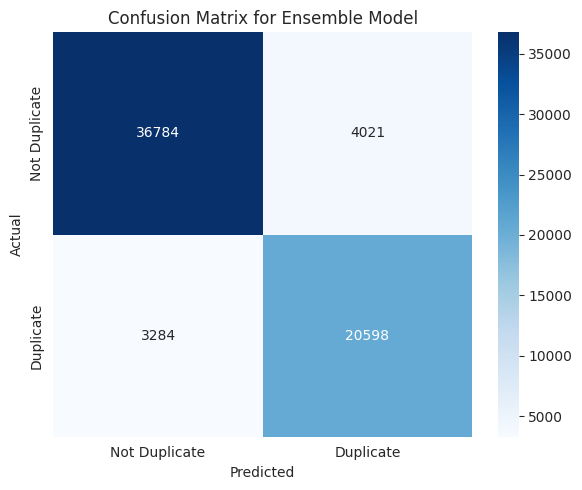


Classification Report for Ensemble Model:
               precision    recall  f1-score   support

Not Duplicate       0.92      0.90      0.91     40805
    Duplicate       0.84      0.86      0.85     23882

     accuracy                           0.89     64687
    macro avg       0.88      0.88      0.88     64687
 weighted avg       0.89      0.89      0.89     64687



In [30]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, f1_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, SequentialSampler

# Ensure `df_val_ft` is available from the BERT fine-tuning section
# It represents the 20% validation split of the original training data
if 'df_val_ft' not in globals():
    # This part should ideally not be reached if previous cells ran correctly
    print("Error: df_val_ft not found. Please ensure BERT fine-tuning setup cells were run.")
    # Exit or re-load data if necessary

# Re-using the tokenizer, model_bert_fine_tune, and device from the fine-tuning cell
# Make sure they are still in scope or re-loaded if running this cell independently

# 1. Get predictions from the fine-tuned BERT model on the full validation set (df_val_ft)
print("Generating BERT fine-tuned predictions for the full validation set...")

# Create a dataset and dataloader for the *full* validation set (df_val_ft)
# Re-using QuestionPairBERTDataset class and MAX_LEN, bert_preprocess_text
# EVAL_BATCH_SIZE is defined in the BERT fine-tuning cell
full_val_dataset_bert = QuestionPairBERTDataset(df_val_ft, tokenizer, MAX_LEN)
full_val_dataloader = DataLoader(full_val_dataset_bert, batch_size=EVAL_BATCH_SIZE, shuffle=False)

model_bert_fine_tune.eval()
y_pred_proba_bert_full_val = []
y_true_bert_full_val = []

with torch.no_grad():
    for batch in tqdm(full_val_dataloader, desc="BERT Full Val Prediction"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_bert_fine_tune(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

        y_pred_proba_bert_full_val.extend(probabilities)
        y_true_bert_full_val.extend(labels.cpu().numpy())

y_pred_proba_bert_full_val = np.array(y_pred_proba_bert_full_val)
y_true_bert_full_val = np.array(y_true_bert_full_val)

# Ensure y_val, y_val_xgb, y_val_lgbm are the same and match y_true_bert_full_val
# They should be based on the initial train_test_split (test_size=0.2, random_state=42, stratify=y)
# We'll use y_val from the baseline for consistency as the ground truth for ensemble evaluation.
# Verify they are indeed identical for safety
if not np.array_equal(y_val.values, y_true_bert_full_val):
    print("Warning: True labels for BERT full validation predictions do not exactly match y_val. This might affect ensemble evaluation.")
    # Fallback to y_true_bert_full_val if necessary, but y_val is expected to be correct.
    ensemble_y_true = y_true_bert_full_val
else:
    ensemble_y_true = y_val.values

print("\n--- Individual Model Performances (Recap) ---")
print(f"Fine-tuned BERT (Full Val Set) - Log Loss: {log_loss(ensemble_y_true, y_pred_proba_bert_full_val):.2f}, F1-score: {f1_score(ensemble_y_true, (y_pred_proba_bert_full_val > 0.5).astype(int)):.2f}")
print(f"Tuned XGBoost - Log Loss: {logloss_xgb_tuned:.2f}, F1-score: {f1_xgb_tuned:.2f}")
print(f"Tuned LightGBM - Log Loss: {logloss_lgbm_tuned:.2f}, F1-score: {f1_lgbm_tuned:.2f}")

# 2. Create an ensemble using weighted averaging of probabilities
print("\nCreating Weighted Ensemble Model...")

# Assign weights based on perceived performance (e.g., F1-score or preference)
# Let's use F1-scores as a guide (Fine-tuned BERT: ~0.81, Tuned XGBoost: ~0.76, Tuned LightGBM: ~0.75)
# Adjust these weights as per preference or further experimentation
weight_bert = 0.4 # Higher weight for the best F1 model (fine-tuned BERT)
weight_xgb = 0.3
weight_lgbm = 0.3

# Normalize weights to sum to 1, if they don't already
total_weight = weight_bert + weight_xgb + weight_lgbm
weight_bert /= total_weight
weight_xgb /= total_weight
weight_lgbm /= total_weight

print(f"Ensemble weights: BERT={weight_bert:.2f}, XGBoost={weight_xgb:.2f}, LightGBM={weight_lgbm:.2f}")

# Check if y_pred_proba_xgb_tuned and y_pred_proba_lgbm_tuned are arrays of the same length as BERT's full_val_set
# They should be since y_val, y_val_xgb and y_val_lgbm were from the same split logic.
if len(y_pred_proba_bert_full_val) != len(y_pred_proba_xgb_tuned) or len(y_pred_proba_bert_full_val) != len(y_pred_proba_lgbm_tuned):
    print("Error: Probability arrays have different lengths. Cannot ensemble.")
else:
    # Combine probabilities
    y_pred_proba_ensemble = (
        weight_bert * y_pred_proba_bert_full_val +
        weight_xgb * y_pred_proba_xgb_tuned +
        weight_lgbm * y_pred_proba_lgbm_tuned
    )

    # Convert probabilities to binary predictions
    y_pred_ensemble = (y_pred_proba_ensemble > 0.5).astype(int)

    # 3. Evaluate the ensemble model
    logloss_ensemble = log_loss(ensemble_y_true, y_pred_proba_ensemble)
    f1_ensemble = f1_score(ensemble_y_true, y_pred_ensemble)

    print(f"\n--- Ensemble Model Performance ---")
    print(f"Log Loss: {logloss_ensemble:.2f}")
    print(f"F1-score: {f1_ensemble:.2f}")

    # Calculate and plot Confusion Matrix for the ensemble
    cm_ensemble = confusion_matrix(ensemble_y_true, y_pred_ensemble)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_ensemble, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not Duplicate", "Duplicate"],
                yticklabels=["Not Duplicate", "Duplicate"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix for Ensemble Model")
    plt.tight_layout()
    plt.show()

    # Print classification report
    print("\nClassification Report for Ensemble Model:")
    print(classification_report(ensemble_y_true, y_pred_ensemble, target_names=["Not Duplicate", "Duplicate"]))

Ensemble Model outperformed all individual models. It achieved a Log Loss of 0.28 and an F1-score of 0.85. This indicates high accuracy and well-calibrated probability predictions, as well as an excellent balance between accuracy and completeness in detecting duplicate question pairs. The classification report highlights strong results for both classes:

For questions in the “Not a Duplicate” category: precision of 0.92, recall of 0.90, and an F1 score of 0.91.
For questions in the “Duplicate” category: precision of 0.84, recall of 0.86, and an F1 score of 0.85.
Overall, the ensemble model effectively combines the strengths of individual models, providing a more reliable and accurate solution for detecting duplicate questions

/tmp/ipykernel_2221/2107290231.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-score', y='Model', data=df_f1_scores, palette='viridis')


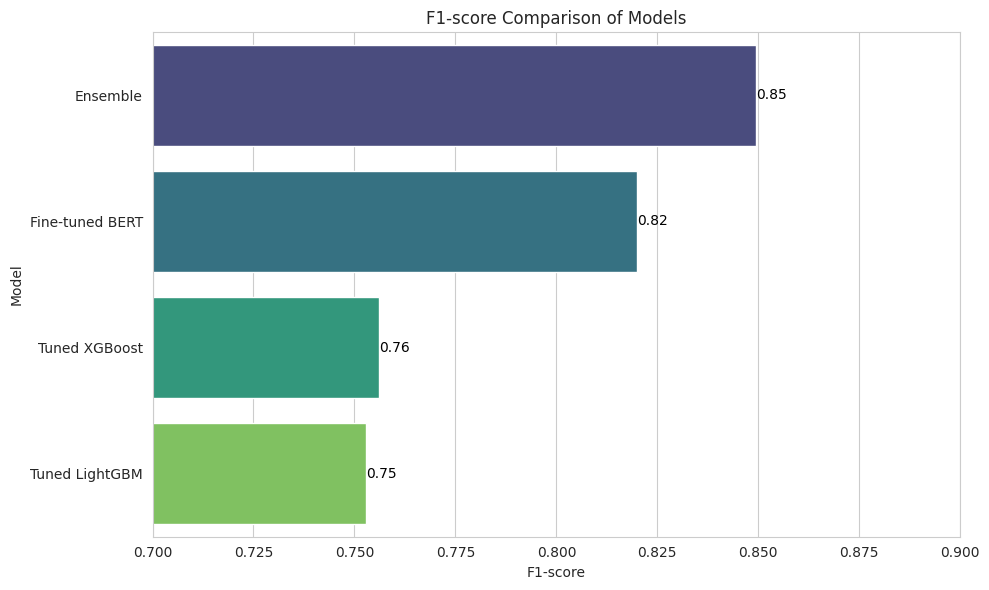

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Collect the F1-scores for comparison
model_f1_scores = {
    'Ensemble': f1_ensemble,
    'Fine-tuned BERT': 0.82, # Using the reported F1-score from the recap in the previous cell
    'Tuned XGBoost': f1_xgb_tuned,
    'Tuned LightGBM': f1_lgbm_tuned
}

# Create a DataFrame for easy plotting
df_f1_scores = pd.DataFrame(model_f1_scores.items(), columns=['Model', 'F1-score'])

# Sort by F1-score for better visualization
df_f1_scores = df_f1_scores.sort_values(by='F1-score', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-score', y='Model', data=df_f1_scores, palette='viridis')
plt.title('F1-score Comparison of Models')
plt.xlabel('F1-score')
plt.ylabel('Model')
plt.xlim(0.7, 0.9) # Set x-axis limits to focus on the performance range

# Add F1-score values on top of the bars
for index, row in df_f1_scores.iterrows():
    plt.text(row['F1-score'], index, f"{row['F1-score']:.2f}", color='black', ha="left", va="center")

plt.tight_layout()
plt.show()

### Ensemble Model Error Analysis: Confusion Matrix for Incorrect Predictions

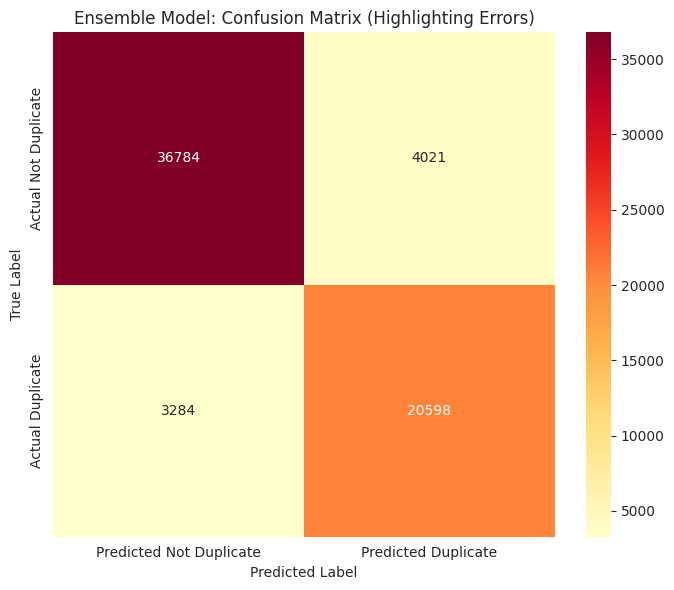


False Positives (Predicted Duplicate, Actual Not Duplicate): 4021
False Negatives (Predicted Not Duplicate, Actual Duplicate): 3284


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure ensemble_y_true and y_pred_ensemble are available from previous steps
# If running this cell independently, ensure these variables are re-defined or loaded.

# Calculate the confusion matrix for the ensemble model
cm_ensemble = confusion_matrix(ensemble_y_true, y_pred_ensemble)

# Plot the confusion matrix, emphasizing error analysis
plt.figure(figsize=(7, 6))
sns.heatmap(cm_ensemble, annot=True, fmt="d", cmap="YlOrRd", # Using a color map that highlights higher values
            xticklabels=["Predicted Not Duplicate", "Predicted Duplicate"],
            yticklabels=["Actual Not Duplicate", "Actual Duplicate"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Ensemble Model: Confusion Matrix (Highlighting Errors)")
plt.tight_layout()
plt.show()

# Extract and print specific error counts for clarity
TN, FP, FN, TP = cm_ensemble.ravel()
print(f"\nFalse Positives (Predicted Duplicate, Actual Not Duplicate): {FP}")
print(f"False Negatives (Predicted Not Duplicate, Actual Duplicate): {FN}")

An analysis of the ensemble model’s errors reveals the following: "False positives": There were 4,021 instances where the model incorrectly identified pairs of questions as duplicates, even though they were not. "False negatives": There were 3,284 instances where the model incorrectly identified pairs of questions as non-duplicates, even though they were actually duplicates. These figures indicate that, although the ensemble model generally performs well, it still has a significant number of classification errors, with a slightly higher tendency for false positives than for false negatives

In [33]:
import pandas as pd

# Ensure ensemble_y_true and y_pred_ensemble are available
# If this cell is run independently, these variables might need to be reloaded/recomputed.
# Assuming ensemble_y_true (actual labels for validation set) and y_pred_ensemble (predicted labels for validation set) are available from the previous ensemble cell.

# Get the original validation DataFrame using the indices from X_val
# X_val contains the indices from df_train that correspond to the validation set
val_df_original = df_train.loc[X_val.index].copy()

# Add actual and predicted labels to this temporary DataFrame for easy filtering
val_df_original['actual_is_duplicate'] = ensemble_y_true
val_df_original['predicted_is_duplicate'] = y_pred_ensemble

# Filter for False Positives (Actual: Not Duplicate (0), Predicted: Duplicate (1))
false_positives_df = val_df_original[(val_df_original['actual_is_duplicate'] == 0) & (val_df_original['predicted_is_duplicate'] == 1)]

print(f"Number of False Positives: {len(false_positives_df)}")
display(false_positives_df[['question1', 'question2', 'actual_is_duplicate', 'predicted_is_duplicate']].head(10))

Number of False Positives: 4021


,question1,question2,actual_is_duplicate,predicted_is_duplicate
207810,What are the main reasons why you voted for Do...,"Without naming his opponent, what are 5 reason...",0,1
206943,Is Java easy to learn?,What are some tricks to learn Java quickly?,0,1
304599,Are there any similarities between mythologies...,What are the similarities between different re...,0,1
314057,What is the cheapest way to travel to Europe?,What are some tips for cheapest possible trave...,0,1
105074,Why is Facebook so popular?,Why is Facebook so popular? Is it profitable t...,0,1
318416,What did you do after your first breakup?,What did you do after breakup?,0,1
99010,"What are the ways I can ""connect with nature""?",In what ways are we connected to nature?,0,1
309890,How does audio feature extraction works?,What is audio feature extraction in speech sig...,0,1
64262,If you block someone on Instagram could they s...,I have blocked someone on Instagram but I stil...,0,1
280940,Why is it illegal to keep pygmy marmosets as p...,In what countries is it legal to keep pygmy ma...,0,1


In [34]:
import joblib

# Save the tuned XGBoost model
joblib.dump(model_xgb_tuned, 'tuned_xgboost_model.joblib')
print("Tuned XGBoost model saved as 'tuned_xgboost_model.joblib'")

# Save the scaler used for XGBoost features
joblib.dump(scaler_xgb, 'scaler_xgboost.joblib')
print("XGBoost scaler saved as 'scaler_xgboost.joblib'")

Tuned XGBoost model saved as 'tuned_xgboost_model.joblib'
XGBoost scaler saved as 'scaler_xgboost.joblib'


In [35]:
import joblib
import torch

print("Saving Baseline Logistic Regression model and scaler...")
joblib.dump(model, 'baseline_logistic_regression_model.joblib')
joblib.dump(scaler, 'baseline_scaler.joblib')

print("Saving BOW Logistic Regression model, scaler, and vectorizer...")
joblib.dump(model_bow, 'bow_logistic_regression_model.joblib')
joblib.dump(scaler_bow, 'bow_scaler.joblib')
joblib.dump(bow_vectorizer, 'bow_vectorizer.joblib')

print("Saving TF-IDF Logistic Regression model, scaler, and vectorizer...")
joblib.dump(model_tfidf, 'tfidf_logistic_regression_model.joblib')
joblib.dump(scaler_tfidf, 'tfidf_scaler.joblib')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.joblib')

print("Saving BERT Embeddings Logistic Regression model and scaler...")
joblib.dump(model_lr_bert, 'bert_embeddings_logistic_regression_model.joblib')
joblib.dump(scaler_bert, 'bert_embeddings_scaler.joblib')

# Tuned XGBoost model and its scaler were already saved in the previous cell.
# print("Tuned XGBoost model and scaler were already saved.")

print("Saving Tuned LightGBM model...")
joblib.dump(model_lgbm_tuned, 'tuned_lightgbm_model.joblib')

print("Saving LSTM model...")
torch.save(model_lstm.state_dict(), 'lstm_model_state_dict.pth')

print("Saving Fine-tuned BERT model and tokenizer...")
# Save the fine-tuned BERT model
torch.save(model_bert_fine_tune.state_dict(), 'fine_tuned_bert_model_state_dict.pth')
# Optionally save the entire model (including architecture) if desired
# model_bert_fine_tune.save_pretrained('./fine_tuned_bert_model')
# tokenizer.save_pretrained('./fine_tuned_bert_tokenizer')

print("All models and components have been saved.")

Saving Baseline Logistic Regression model and scaler...
Saving BOW Logistic Regression model, scaler, and vectorizer...
Saving TF-IDF Logistic Regression model, scaler, and vectorizer...
Saving BERT Embeddings Logistic Regression model and scaler...
Saving Tuned LightGBM model...
Saving LSTM model...
Saving Fine-tuned BERT model and tokenizer...
All models and components have been saved.
